<a href="https://colab.research.google.com/github/okiaahhbb/BlinkingHeart/blob/main/Class1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [4]:
df = pd.read_csv("/content/drive/MyDrive/employee_attrition_dataset.csv")

In [6]:
df.head(10)

,Age,Gender,Department,Education,DistanceFromHome_km,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,OverTime,NumProjects,PerformanceRating,PromotionLast5Years,Attrition
0,56,Male,IT,High School,9,60322.18,12,4,1,No,6,1,No,1
1,46,Female,IT,High School,29,30849.18,18,4,4,No,5,3,No,0
2,32,Male,HR,Master,38,38601.00,2,2,1,Yes,1,1,No,1
3,25,Male,IT,Bachelor,1,27046.59,19,4,4,No,4,5,No,0
4,38,Female,Sales,Master,30,24313.08,16,3,1,Yes,6,5,No,1
5,56,Female,Sales,High School,32,31402.12,10,3,2,No,6,2,Yes,1
6,36,Female,Sales,Master,23,32854.04,16,5,3,Yes,6,4,No,1
7,40,Male,Operations,PhD,39,31470.54,11,2,1,No,9,2,No,1
8,28,Male,IT,High School,10,43628.27,11,1,3,No,8,4,No,0
9,28,Female,Finance,PhD,44,43506.44,19,2,3,No,7,1,Yes,1


missing

In [7]:

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Age                    0
Gender                 0
Department             0
Education              0
DistanceFromHome_km    0
MonthlyIncome          0
YearsAtCompany         0
JobSatisfaction        0
WorkLifeBalance        0
OverTime               0
NumProjects            0
PerformanceRating      0
PromotionLast5Years    0
Attrition              0
dtype: int64

Duplicate Rows: 0

Data Types:
Age                      int64
Gender                  object
Department              object
Education               object
DistanceFromHome_km      int64
MonthlyIncome          float64
YearsAtCompany           int64
JobSatisfaction          int64
WorkLifeBalance          int64
OverTime                object
NumProjects              int64
PerformanceRating        int64
PromotionLast5Years     object
Attrition                int64
dtype: object


In [8]:
df = df.fillna(method='ffill')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 14)


/tmp/ipykernel_947/1629777170.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,Age,Gender,Department,Education,DistanceFromHome_km,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,OverTime,NumProjects,PerformanceRating,PromotionLast5Years,Attrition
0,56,Male,IT,High School,9,60322.18,12,4,1,No,6,1,No,1
1,46,Female,IT,High School,29,30849.18,18,4,4,No,5,3,No,0
2,32,Male,HR,Master,38,38601.00,2,2,1,Yes,1,1,No,1
3,25,Male,IT,Bachelor,1,27046.59,19,4,4,No,4,5,No,0
4,38,Female,Sales,Master,30,24313.08,16,3,1,Yes,6,5,No,1


In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [11]:
le

LabelEncoder()

In [12]:
df["Gender"] = le.fit_transform(df["Gender"])
df["Department"] = le.fit_transform(df["Department"])
df["Education"] = le.fit_transform(df["Education"])
df["OverTime"] = le.fit_transform(df["OverTime"])
df["PromotionLast5Years"] = le.fit_transform(df["PromotionLast5Years"])

In [13]:
df.head()

,Age,Gender,Department,Education,DistanceFromHome_km,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,OverTime,NumProjects,PerformanceRating,PromotionLast5Years,Attrition
0,56,1,2,1,9,60322.18,12,4,1,0,6,1,0,1
1,46,0,2,1,29,30849.18,18,4,4,0,5,3,0,0
2,32,1,1,2,38,38601.00,2,2,1,1,1,1,0,1
3,25,1,2,0,1,27046.59,19,4,4,0,4,5,0,0
4,38,0,4,2,30,24313.08,16,3,1,1,6,5,0,1


In [14]:
# Features and Target

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [17]:
lr = LogisticRegression(random_state=42)

dt = DecisionTreeClassifier(random_state=42)

rf = RandomForestClassifier(random_state=42)

In [18]:
lr.fit(X_train, y_train)

dt.fit(X_train, y_train)

rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
def evaluation_of_classifier(clf, xtrain, ytrain, xtest, ytest, clf_name):

    # Train Model
    clf.fit(xtrain, ytrain)

    # Prediction
    ypred = clf.predict(xtest)

    # Probability (ROC-AUC এর জন্য)
    yprob = clf.predict_proba(xtest)[:,1]

    # Metrics
    accuracy = accuracy_score(ytest, ypred)
    precision = precision_score(ytest, ypred)
    recall = recall_score(ytest, ypred)
    f1 = f1_score(ytest, ypred)
    roc = roc_auc_score(ytest, yprob)

    print("="*50)
    print(clf_name)
    print("="*50)

    print(classification_report(ytest, ypred))

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc)

    # Confusion Matrix
    cm = confusion_matrix(ytest, ypred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {clf_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return [clf_name, accuracy, precision, recall, f1, roc]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
              precision    recall  f1-score   support

           0       0.64      0.58      0.61       850
           1       0.71      0.75      0.73      1150

    accuracy                           0.68      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.68      0.68      0.68      2000

Accuracy : 0.6805
Precision: 0.7089125102207686
Recall   : 0.7539130434782608
F1 Score : 0.7307206068268015
ROC-AUC  : 0.7425084398976983


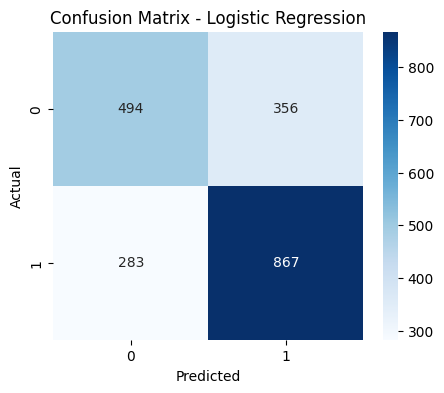

Decision Tree
              precision    recall  f1-score   support

           0       0.61      0.60      0.60       850
           1       0.71      0.71      0.71      1150

    accuracy                           0.67      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.67      0.66      2000

Accuracy : 0.665
Precision: 0.7065404475043029
Recall   : 0.7139130434782609
F1 Score : 0.7102076124567474
ROC-AUC  : 0.6563682864450129


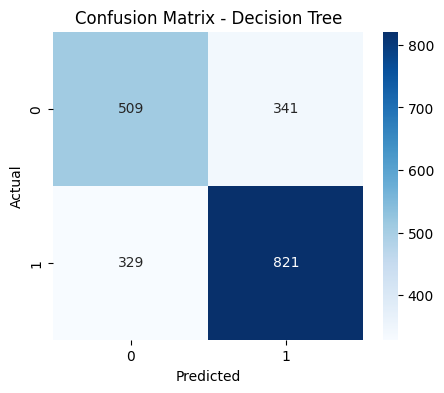

Random Forest
              precision    recall  f1-score   support

           0       0.72      0.67      0.69       850
           1       0.77      0.81      0.78      1150

    accuracy                           0.75      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.74      0.75      0.74      2000

Accuracy : 0.746
Precision: 0.7652892561983471
Recall   : 0.8052173913043478
F1 Score : 0.7847457627118644
ROC-AUC  : 0.8167176470588234


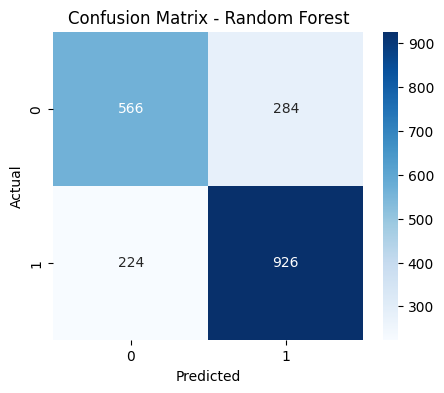

In [24]:
results = []

results.append(
    evaluation_of_classifier(
        lr, X_train, y_train, X_test, y_test,
        "Logistic Regression"
    )
)

results.append(
    evaluation_of_classifier(
        dt, X_train, y_train, X_test, y_test,
        "Decision Tree"
    )
)

results.append(
    evaluation_of_classifier(
        rf, X_train, y_train, X_test, y_test,
        "Random Forest"
    )
)

In [25]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6805,0.708913,0.753913,0.730721,0.742508
1,Decision Tree,0.6650,0.706540,0.713913,0.710208,0.656368
2,Random Forest,0.7460,0.765289,0.805217,0.784746,0.816718


In [26]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(best_model)

Model        Random Forest
Accuracy             0.746
Precision         0.765289
Recall            0.805217
F1 Score          0.784746
ROC-AUC           0.816718
Name: 2, dtype: object
